# 1 · The Block Blast environment

Block Blast is a single-player puzzle on an **8×8 grid**. The player receives pieces
(7 shapes, randomly rotated) and places them anywhere they fit. Every full row
or column is cleared and scores points. The game ends when no piece fits.

We implemented it as two [Gymnasium](https://gymnasium.farama.org/) environments:

| | `BlockBlastEnv` (1P) | `BlockBlast3PEnv` (3P, the real game) |
|---|---|---|
| Pieces | one at a time | three per round, played in any order |
| Actions | `Discrete(64)`: top-left cell | `Discrete(192)`: piece × cell |
| Reward | shaped: survival + lines + emptiness − penalty if no free 3×3 | `10·(n² + combo)` per clear, 0.1 otherwise |

Both observations include the valid-placement mask **and the afterstates**: the
board that would result from every candidate placement. This is what the Deep
Value Network (notebook 2) exploits.

In [6]:
# `uv sync` installs the project; this line only lets the notebook run without it.
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(4)
%matplotlib inline

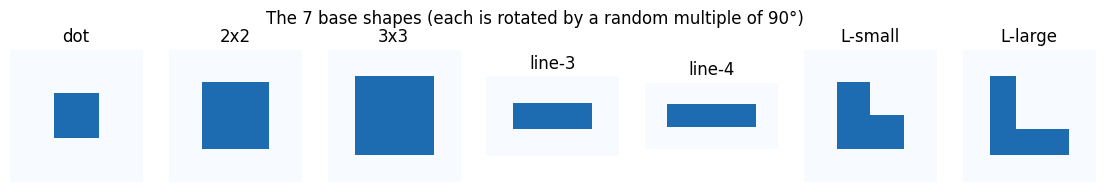

In [7]:
from blockblast import BlockBlastEnv, BlockBlast3PEnv
from blockblast.block_blast_3p_env import SHAPES
from blockblast.rendering import EpisodeRenderer, record_episode
from common.policies import RandomPolicy

fig, axes = plt.subplots(1, len(SHAPES), figsize=(14, 2.2))
for ax, (name, grid) in zip(axes, SHAPES.items()):
    ax.imshow(np.pad(grid, 1), cmap="Blues", vmin=0, vmax=1.3)
    ax.set_title(name); ax.axis("off")
fig.suptitle("The 7 base shapes (each is rotated by a random multiple of 90°)")
plt.show()

## Observations

The 3P observation is a dictionary. `placements_result` holds, for each of the
192 actions, the board after the placement and line clears.

In [8]:
env = BlockBlast3PEnv()
obs, _ = env.reset(seed=0)
for key, value in obs.items():
    print(f"{key:18s} shape={str(np.shape(value)):18s} dtype={np.asarray(value).dtype}")
print("valid actions at the start:", int(obs["valid_placements"].sum()), "/ 192")

board              shape=(8, 8)             dtype=int8
pieces             shape=(3, 5, 5)          dtype=int8
pieces_used        shape=(3,)               dtype=int8
combo              shape=(1,)               dtype=int32
valid_placements   shape=(3, 8, 8)          dtype=int8
placements_result  shape=(3, 8, 8, 8, 8)    dtype=int8
valid actions at the start: 168 / 192


## A random game

Below, a random agent plays one game. Each frame shows the piece just placed
(white outline) and the lines it completes (gold). Faded pieces in the tray are
already used for this round.

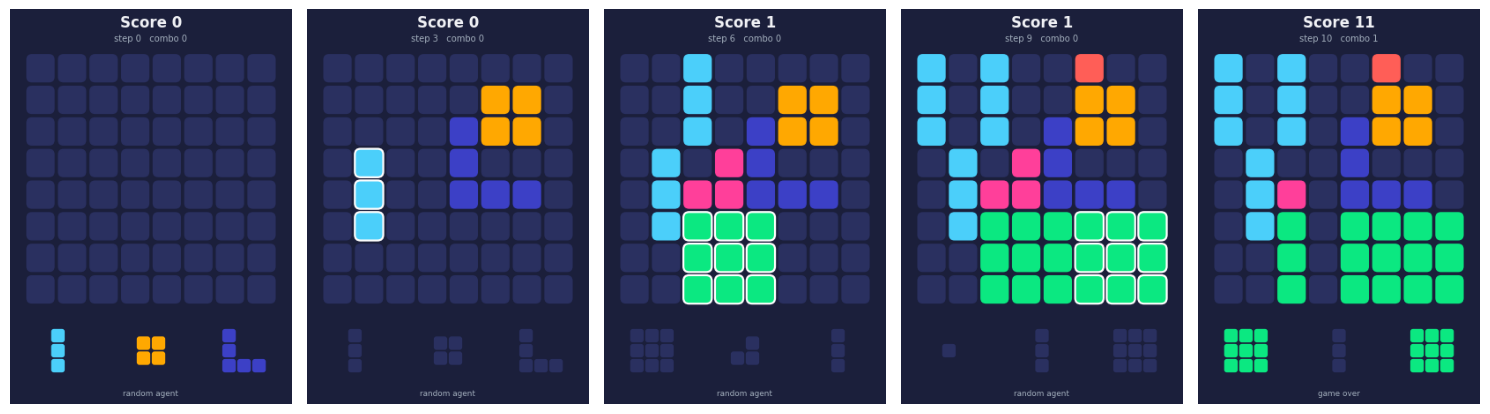

In [9]:
frames = record_episode(BlockBlast3PEnv(), RandomPolicy(seed=0), seed=1, max_steps=40, caption="random agent")
picks = np.linspace(0, len(frames) - 1, 5).astype(int)
fig, axes = plt.subplots(1, 5, figsize=(15, 4.3))
for ax, i in zip(axes, picks):
    ax.imshow(frames[i]); ax.axis("off")
plt.tight_layout(); plt.show()

## How hard is it?

A random agent survives about 10 placements. Most moves score nothing, which
makes the reward signal sparse, and in 3P the number of ways to play a round
explodes: 3! orderings × up to 64 cells per piece.

In [10]:
from common.evaluation import run_episodes, print_table

results = {
    "random 1P": run_episodes(BlockBlastEnv(), RandomPolicy(0), 500, seed=0, progress=False),
    "random 3P": run_episodes(BlockBlast3PEnv(), RandomPolicy(0), 500, seed=0, progress=False),
}
print_table(results, "Random agent, 500 episodes")

env = BlockBlast3PEnv(); env.reset(seed=0)
n_sequences = sum(1 for _ in env.iter_t_plus_3_sequences(gamma=0.99))
print(f"\nValid 3-placement sequences for the first round of seed 0: {n_sequences:,}")


  Random agent, 500 episodes
policy                    n    mean ret     ± sem     median  mean len  ms/dec
------------------------------------------------------------------------------
random 1P               500       -46.5       1.7      -47.0      11.2     0.0
random 3P               500        22.6       1.8       10.7      11.9     0.0

Valid 3-placement sequences for the first round of seed 0: 849,600
